<a href="https://colab.research.google.com/github/paullsa/paullsa/blob/main/Titanic_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Second attempt at the Titanic challenge

This time splitting training and validation data prior to testing on test dataset

## Import libraries and data

In [ ]:
# data analysis and wrangling
import pandas as pd
import numpy as np

# visualization
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# machine learning
from sklearn.linear_model import LinearRegression,LogisticRegression, RidgeClassifierCV
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn import preprocessing
from sklearn.model_selection import train_test_split,GridSearchCV,RandomizedSearchCV
from sklearn.metrics import r2_score,mean_squared_error,roc_curve,auc,accuracy_score
from sklearn.neighbors import KNeighborsClassifier

import statsmodels as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

/usr/local/lib/python3.7/dist-packages/statsmodels/tools/_testing.py:19: FutureWarning: pandas.util.testing is deprecated. Use the functions in the public API at pandas.testing instead.
  import pandas.util.testing as tm


In [ ]:
#Data is in Content - Drive - MyDrive - Python Data

from google.colab import drive
drive.mount('/content/drive')

#df=pd.read_csv('/content/drive/MyDrive/Python Data /train.csv')

train_df = pd.read_csv('/content/drive/MyDrive/Python Data /train.csv')
test_df = pd.read_csv('/content/drive/MyDrive/Python Data /test.csv')
combine = [train_df, test_df]

Mounted at /content/drive


In [ ]:
#lets have a look at the dataset
train_df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [ ]:
#convert sex into binary variable and drop original variable

train_df['sex'] = train_df['Sex'].replace(['female', 'male'], [0, 1])
train_df.drop('Sex',axis=1, inplace=True)
train_df

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,sex
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,NaN,S,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,C85,C,0
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,C123,S,0
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,NaN,S,1
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",27.0,0,0,211536,13.0000,NaN,S,1
887,888,1,1,"Graham, Miss. Margaret Edith",19.0,0,0,112053,30.0000,B42,S,0
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",NaN,1,2,W./C. 6607,23.4500,NaN,S,0
889,890,1,1,"Behr, Mr. Karl Howell",26.0,0,0,111369,30.0000,C148,C,1


In [ ]:
#drop variables we're not interested in
train_df = train_df.drop(["PassengerId","Name","Ticket","Cabin","Embarked"], axis=1)

In [ ]:
train_df

,Survived,Pclass,Age,SibSp,Parch,Fare,sex
0,0,3,22.0,1,0,7.2500,1
1,1,1,38.0,1,0,71.2833,0
2,1,3,26.0,0,0,7.9250,0
3,1,1,35.0,1,0,53.1000,0
4,0,3,35.0,0,0,8.0500,1
...,...,...,...,...,...,...,...
886,0,2,27.0,0,0,13.0000,1
887,1,1,19.0,0,0,30.0000,0
888,0,3,NaN,1,2,23.4500,0
889,1,1,26.0,0,0,30.0000,1


In [ ]:
#check for missing values
train_df.isna().sum()

Survived      0
Pclass        0
Age         177
SibSp         0
Parch         0
Fare          0
sex           0
dtype: int64

In [ ]:
#give age average value for dataset
train_df['Age'].fillna((train_df['Age'].mean()), inplace=True)
train_df.isna().sum()

Survived    0
Pclass      0
Age         0
SibSp       0
Parch       0
Fare        0
sex         0
dtype: int64

In [ ]:
#calculate variance inflation factors
X1 = sm.tools.add_constant(train_df)
#calculate the VIF and make the results a series.
series1 = pd.Series([variance_inflation_factor(X1.values,i) for i in range(X1.shape[1])],index=X1.columns)
print('Initial VIF: \n\n{}\n'.format(series1))

Initial VIF: 

const       42.090195
Survived     1.652699
Pclass       1.811851
Age          1.245368
SibSp        1.290239
Parch        1.317406
Fare         1.595698
sex          1.518682
dtype: float64



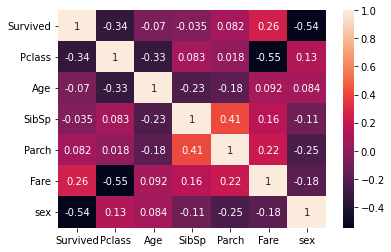

In [ ]:
#correlation between independant and dependant variables
sns.heatmap(train_df.corr(), annot=True)

#Create test and training data

In [ ]:
# create a dataFrame of independent variables / model factors
X = train_df.drop(['Survived'],axis=1)

# create a series of the dependent variable / variable to predict
y = train_df.Survived  

# scaling the feature variables - makes sure factors are all on same scale
X_scaled = preprocessing.scale(X)

# preprocessing.scale() returns a 2-d array not a DataFrame so we make our scaled variables
# a DataFrame.
X_scaled = pd.DataFrame(X_scaled,columns=X.columns)

# split our data into training and testing data
X_train,X_test,y_train,y_test = train_test_split(X_scaled,y,test_size=0.3,random_state=0)


## Build linear model

In [ ]:
# initialize the LinearRegression model
model = LinearRegression()  

# fit the model with the training data
model.fit(X_train,y_train)  

# make prediction with the fitted model
y_pred = model.predict(X_test)  

# score the model on the train set
print('Train score: {}\n'.format(model.score(X_train,y_train)))
# score the model on the test set
print('Test score: {}\n'.format(model.score(X_test,y_test)))
# calculate the overall accuracy of the model
print('Overall model accuracy: {}\n'.format(r2_score(y_test,y_pred)))
# compute the mean squared error of the model
print('Mean Squared Error: {}'.format(mean_squared_error(y_test,y_pred)))

Train score: 0.3938772553882839

Test score: 0.3951535704312691

Overall model accuracy: 0.3951535704312691

Mean Squared Error: 0.141476665414829


https://www.linkedin.com/pulse/what-i-learned-analyzing-famous-titanic-dateset-murilo-gustineli

Score Model

In [ ]:
# make prediction with the fitted model
y_pred = model.predict(X_test)  

#create dataset of scored data
df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})

In [ ]:
y_temp = model.predict(train_df)
y_temp

ValueError: ignored

In [ ]:
#score whole dataset
predicted = model.predict(X_train)
predicted_df = pd.DataFrame(data=predicted, columns=['y_hat'], 
                            index=X_train.index.copy())
df_out = pd.merge(X_train, predicted_df, how ='left', left_index=True, 
                 right_index=True)
df_out

,Pclass,Age,SibSp,Parch,Fare,sex,y_hat
857,-1.566107,1.639196,-0.474545,-0.473674,-0.113846,0.737695,0.321791
52,-1.566107,1.485287,0.432793,-0.473674,0.896497,-1.355574,0.825732
386,0.827377,-2.208522,4.062148,2.008933,0.295895,0.737695,0.023457
124,-1.566107,1.870059,-0.474545,0.767630,0.907738,0.737695,0.304241
578,0.827377,0.000000,0.432793,-0.473674,-0.357308,-1.355574,0.593008
...,...,...,...,...,...,...,...
835,-1.566107,0.715743,0.432793,0.767630,1.025945,-1.355574,0.867337
192,0.827377,-0.823344,0.432793,-0.473674,-0.490280,-1.355574,0.654069
629,0.827377,0.000000,-0.474545,-0.473674,-0.492714,0.737695,0.119002
559,0.827377,0.484880,0.432793,-0.473674,-0.298078,-1.355574,0.556655


In [ ]:
#output to csv
df_out.to_csv('/content/drive/MyDrive/Python Data /titanic_scored.csv')

## Build logistic model

In [ ]:
#initialise logistic model
model = LogisticRegression()

#fit model with training data
model.fit(X=X_train, y=y_train)

#make model predictions
y_pred = model.predict(X_test)

# score the model on the train set
print('Train score: {}\n'.format(model.score(X_train,y_train)))
# score the model on the test set
print('Test score: {}\n'.format(model.score(X_test,y_test)))
# calculate the overall accuracy of the model
print('Overall model accuracy: {}\n'.format(r2_score(y_test,y_pred)))
# compute the mean squared error of the model
print('Mean Squared Error: {}'.format(mean_squared_error(y_test,y_pred)))

Train score: 0.7961476725521669

Test score: 0.8059701492537313

Overall model accuracy: 0.17047619047619045

Mean Squared Error: 0.19402985074626866


In [ ]:
# make prediction with the fitted model
y_pred = model.predict(X_test)  

#create dataset of scored data
df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})

In [ ]:
#score whole dataset
#create array of predictions
predicted = model.predict(X_train)
#create dataframe containing only predictions and index
predicted_df = pd.DataFrame(data=predicted, columns=['y_hat'],index=X_train.index.copy())
#merge predictions with original data
df_out = pd.merge(X_train, predicted_df, how ='left', left_index=True,right_index=True)
df_out

,Pclass,Age,SibSp,Parch,Fare,sex,y_hat
857,-1.566107,1.639196,-0.474545,-0.473674,-0.113846,0.737695,0
52,-1.566107,1.485287,0.432793,-0.473674,0.896497,-1.355574,1
386,0.827377,-2.208522,4.062148,2.008933,0.295895,0.737695,0
124,-1.566107,1.870059,-0.474545,0.767630,0.907738,0.737695,0
578,0.827377,0.000000,0.432793,-0.473674,-0.357308,-1.355574,1
...,...,...,...,...,...,...,...
835,-1.566107,0.715743,0.432793,0.767630,1.025945,-1.355574,1
192,0.827377,-0.823344,0.432793,-0.473674,-0.490280,-1.355574,1
629,0.827377,0.000000,-0.474545,-0.473674,-0.492714,0.737695,0
559,0.827377,0.484880,0.432793,-0.473674,-0.298078,-1.355574,1


## Confusion matrix

In [ ]:
#confusion matrix
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix
predictions = cross_val_predict(model, X_train, y_train,cv=3)
confusion_matrix(y_train, predictions)

array([[327,  54],
       [ 75, 167]])

## Precision, recall and f-score

In [ ]:
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import f1_score

print("Precision:", precision_score(y_train, predictions))
print("Recall:",recall_score(y_train, predictions))
print("F1 Score:",f1_score(y_train,predictions))

Precision: 0.755656108597285
Recall: 0.6900826446280992
F1 Score: 0.7213822894168467


##  Plot ROC Curve

https://www.kaggle.com/elwlslek/titanic-roc-curve


In [ ]:
# Need to score whole datafram and have predictions in same dataframe
from sklearn.metrics import roc_auc_score
r_a_score = roc_auc_score(y_train,y_scores)
print("ROC AUC Score:", r_a_score)

NameError: ignored

No Skill: ROC AUC=0.500
Logistic: ROC AUC=0.903


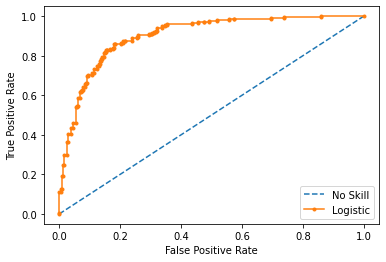

In [ ]:
#https://machinelearningmastery.com/roc-curves-and-precision-recall-curves-for-classification-in-python/

# roc curve and auc
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from matplotlib import pyplot

# generate 2 class dataset
X, y = make_classification(n_samples=1000, n_classes=2, random_state=1)

# split into train/test sets
trainX, testX, trainy, testy = train_test_split(X, y, test_size=0.5, random_state=2)

# generate a no skill prediction (majority class)
ns_probs = [0 for _ in range(len(testy))]

# fit a model
model = LogisticRegression(solver='lbfgs')
model.fit(trainX, trainy)

# predict probabilities
lr_probs = model.predict_proba(testX)

# keep probabilities for the positive outcome only
lr_probs = lr_probs[:, 1]

# calculate scores
ns_auc = roc_auc_score(testy, ns_probs)
lr_auc = roc_auc_score(testy, lr_probs)

# summarize scores
print('No Skill: ROC AUC=%.3f' % (ns_auc))
print('Logistic: ROC AUC=%.3f' % (lr_auc))

# calculate roc curves
ns_fpr, ns_tpr, _ = roc_curve(testy, ns_probs)
lr_fpr, lr_tpr, _ = roc_curve(testy, lr_probs)

# plot the roc curve for the model
pyplot.plot(ns_fpr, ns_tpr, linestyle='--', label='No Skill')
pyplot.plot(lr_fpr, lr_tpr, marker='.', label='Logistic')

# axis labels
pyplot.xlabel('False Positive Rate')
pyplot.ylabel('True Positive Rate')

# show the legend
pyplot.legend()

# show the plot
pyplot.show()


## Build K Nearest Neighbours

https://medium.com/analytics-vidhya/titanic-machine-learning-by-k-nearest-neighbors-knn-algorithm-530d8bdd8323

In [ ]:
k_range = range(1, 26)
scores = []
for k in k_range:
  knn = KNeighborsClassifier(n_neighbors=k)
  knn.fit(X_train,y_train)
  y_pred = knn.predict(X_test)
  # scores.append(metrics.accuracy_score(y_test,y_pred))
print(scores)

[]


ValueError: ignored

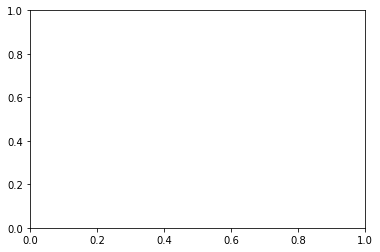

In [ ]:
import matplotlib.pyplot as plt
plt.plot(k_range,scores)
plt.xlabel('Value of K for KNN')
plt.ylabel('Testing Accuracy')